<a href="https://colab.research.google.com/github/adrianamalmeida001/projeto-tecnicas-programacao-adatech/blob/main/Projeto_t%C3%A9cnicas_de_programa%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Tratamento e análise de dados com Pandas – Adatech / CaixaVerso

## Análise de Dados sobre Consumo de Energia

Este projeto tem como objetivo realizar a análise exploratória e o tratamento de dados relacionados ao consumo de energia, utilizando a biblioteca Pandas em Python.

Os dados analisados são de fonte pública e abordam informações sobre consumo energético, fontes de energia e indicadores relacionados ao uso de energia ao longo do tempo.

O projeto faz parte das atividades do módulo 2 - Técnicas de Programação, promovido pela Adatech em parceria com a Caixa.

In [21]:
# importa o pandas e a biblioteca p gráficos
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# ler o dataset
df = pd.read_csv("owid-energy-data.csv")

In [25]:
# mostrar um resumo do dataset, quantidade de linhas e colunas, tipos de variáveis, memória usada.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23232 entries, 0 to 23231
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [26]:
#verifica valores nulos
df.isna().sum()

,0
country,0
year,0
iso_code,6098
population,4472
gdp,11452
...,...
wind_elec_per_capita,14995
wind_electricity,13904
wind_energy_per_capita,18087
wind_share_elec,15749


In [27]:
#mostra todos os nomes das colunas
list(df.columns)

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_cons_change_pct',
 'biofuel_cons_change_twh',
 'biofuel_cons_per_capita',
 'biofuel_consumption',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'biofuel_share_energy',
 'carbon_intensity_elec',
 'coal_cons_change_pct',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_pct',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'coal_share_energy',
 'electricity_demand',
 'electricity_demand_per_capita',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_cons_change_twh',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_energy_per_capita',
 'fossil_fuel_consumption',
 'fossil_share_elec',
 'fossil_share_energy',
 'gas_cons_chan

In [28]:
# cria um dataframe apenas com as colunas que necessito para a análise e mostrar o resultado
colunas_projeto = [
    'country',
    'year',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'fossil_share_energy',
    'renewables_share_energy',
    'solar_share_energy',
    'wind_share_energy',
    'hydro_share_energy'
]

df_tratado = df[colunas_projeto]

df_tratado.head()

,country,year,population,gdp,primary_energy_consumption,energy_per_capita,fossil_share_energy,renewables_share_energy,solar_share_energy,wind_share_energy,hydro_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# conta valores nulos por coluna do df tratado
df_tratado.isna().sum()

,0
country,0
year,0
population,4472
gdp,11452
primary_energy_consumption,9977
energy_per_capita,12146
fossil_share_energy,16853
renewables_share_energy,16853
solar_share_energy,16853
wind_share_energy,16853


In [30]:
# cria um dataframe específico para as matrizes energéticas, removendo as linhas onde faltam dados dessas colunas e mostra resultado

df_matriz = df_tratado.dropna(
    subset=[
        'fossil_share_energy',
        'renewables_share_energy',
        'solar_share_energy',
        'wind_share_energy',
        'hydro_share_energy'
    ]
)

df_matriz.shape

(6379, 11)

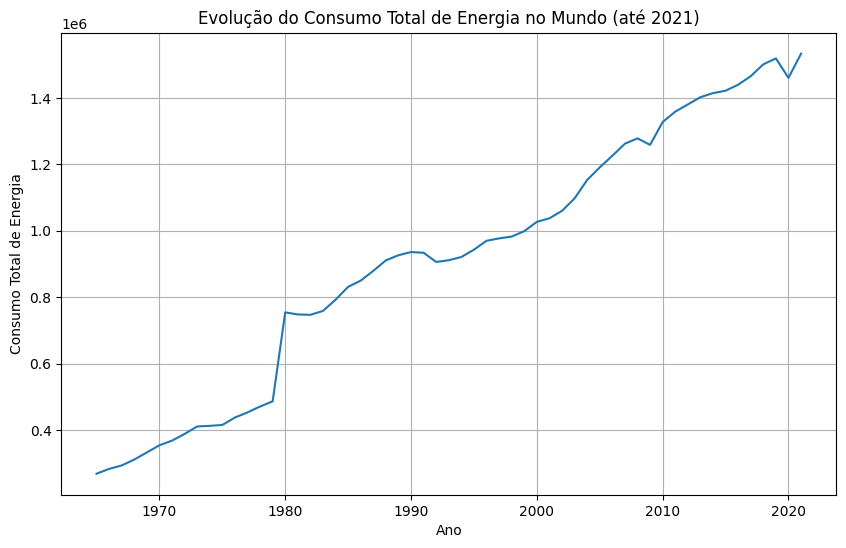

In [33]:
# PERGUNTA 1. Como o consumo total de energia evoluiu ao longo dos anos no mundo?

# agrupamento por ano e soma o resultado ( removendo as linhas onde faltam dados)
consumo_mundial_por_ano = (
    df_tratado
    .dropna(subset=['primary_energy_consumption'])
    .groupby('year')['primary_energy_consumption']
    .sum()
)

# filtra os dados até 2021
consumo_ate_2021 = consumo_mundial_por_ano[consumo_mundial_por_ano.index <= 2021]

# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))
plt.plot(consumo_ate_2021)
plt.title("Evolução do Consumo Total de Energia no Mundo (até 2021)")
plt.xlabel("Ano")
plt.ylabel("Consumo Total de Energia")
plt.grid(True)
plt.show()

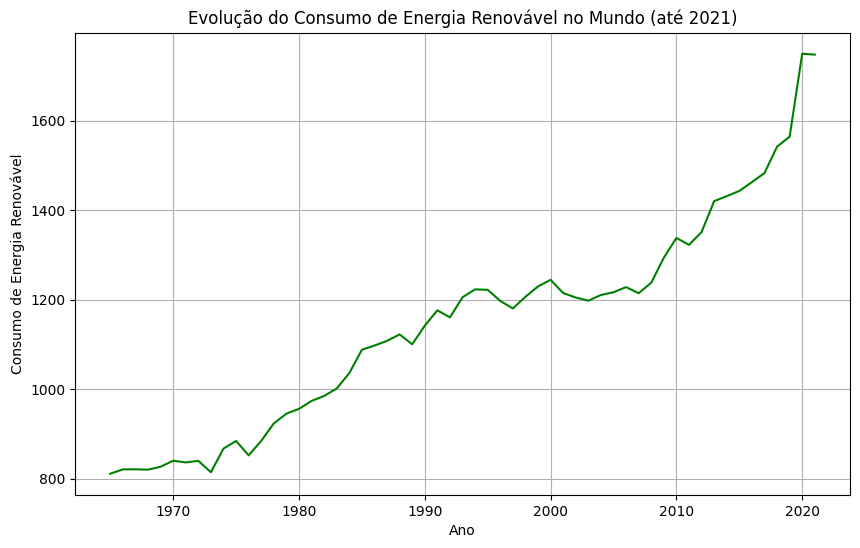

In [38]:
# PERGUNTA 2 - Há tendência de crescimento no consumo de energia renovável ao longo dos anos?

# agrupamento por ano e soma o resultado ( removendo as linhas onde faltam dados)
renovavel_mundial_por_ano = (
    df_tratado
    .dropna(subset=['renewables_share_energy'])
    .groupby('year')['renewables_share_energy']
    .sum()
)

# filtra os dados até 2021
renovavel_ate_2021 = renovavel_mundial_por_ano[renovavel_mundial_por_ano.index <= 2021]

# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))
plt.plot(renovavel_ate_2021, color='green')
plt.title("Evolução do Consumo de Energia Renovável no Mundo (até 2021)")
plt.xlabel("Ano")
plt.ylabel("Consumo de Energia Renovável")
plt.grid(True)
plt.show()

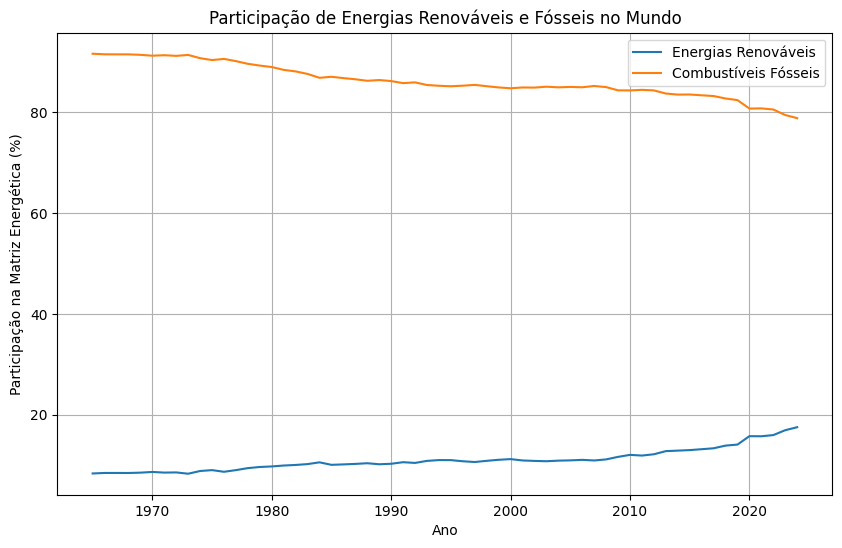

In [59]:
# PERGUNTA 3 - Existe diferença entre a participação de energia renovável e de energia fóssil no mundo ao longo do tempo?

# cáculo da média mundial
matriz_mundial = (
    df_matriz
    .groupby('year')[['renewables_share_energy', 'fossil_share_energy']]
    .mean()
    .reset_index()
)

# criação do gráfico de linhas com o resultado
plt.figure(figsize=(10, 6))

plt.plot(
    matriz_mundial['year'],
    matriz_mundial['renewables_share_energy'],
    label='Energias Renováveis'
)

plt.plot(
    matriz_mundial['year'],
    matriz_mundial['fossil_share_energy'],
    label='Combustíveis Fósseis'
)

plt.title('Participação de Energias Renováveis e Fósseis no Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação na Matriz Energética (%)')
plt.legend()
plt.grid(True)

plt.show()


In [49]:
# PERGUNTA 4 - Quais países apresentam maior consumo de energia per capita?

# remove valores nulos
df_per_capita = df_tratado.dropna(subset=['energy_per_capita'])

# calcula a média de cada país
consumo_per_capita_paises = (
    df_per_capita
    .groupby('country')['energy_per_capita']
    .mean()
)

# ordena o resultado do maior para o menor
consumo_per_capita_paises_ordenado = consumo_per_capita_paises.sort_values(ascending=False)

# mostra o resultado nos 10 países que mais consomem
consumo_per_capita_paises_ordenado.head(10)


,energy_per_capita
country,
Netherlands Antilles,280405.755548
United States Virgin Islands,211136.781864
Qatar,185441.816950
Bahrain,148250.522023
United Arab Emirates,124130.426217
Iceland,108331.059817
Canada,106041.422950
Norway,100213.050917
Singapore,98865.235600


In [51]:
# PERGUNTA 5 - Quais países apresentam maior dependência de combustíveis fósseis em sua matriz energética?

# agrupamento por país e cálculo da média
dependencia_fossil_paises = (
    df_matriz
    .groupby('country')['fossil_share_energy']
    .mean()
)

# ordena o resultado do maior para o menor
dependencia_fossil_paises_ordenado = dependencia_fossil_paises.sort_values(ascending=False)

# mostra o resultado nos 10 países que mais dependem
dependencia_fossil_paises_ordenado.head(10)

,fossil_share_energy
country,
Turkmenistan,99.993525
Kuwait,99.991283
Saudi Arabia,99.975667
Qatar,99.958850
Oman,99.932600
Trinidad and Tobago,99.931383
Hong Kong,99.903033
Singapore,99.831967
Other Northern Africa (EI),99.767400


In [57]:
# PERGUNTA 6 - Existem países cuja matriz energética é majoritariamente renovável?

# calcula média de renováveis por país
renovaveis_paises = (
    df_matriz
    .groupby('country')['renewables_share_energy']
    .mean()
)

# filtra países com matriz renovável > 50%
paises_renovaveis = renovaveis_paises[renovaveis_paises > 50]

# ordena o resultado do maior para o menor
paises_renovaveis_ordenado = paises_renovaveis.sort_values(ascending=False)

# mostra o resultado
paises_renovaveis_ordenado

,renewables_share_energy
country,
Norway,67.101683
Iceland,62.202067


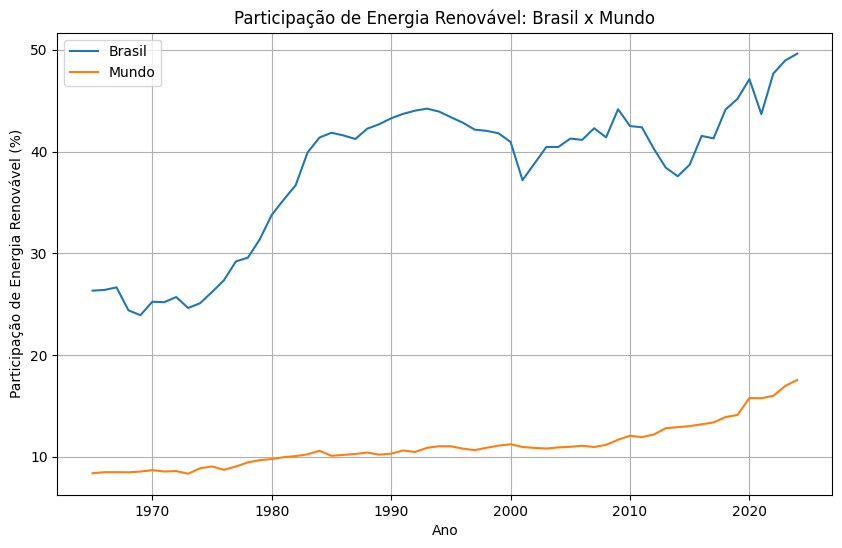

In [56]:
# PERGUNTA 7 - Como a participação de energia renovável do Brasil se compara à média mundial ao longo do tempo?

# filtra os dados do Brasil com a participação de energia renovável por ano
brasil_renovavel = df_matriz[df_matriz['country'] == 'Brazil'][['year', 'renewables_share_energy']]

# média mundial
mundo_renovavel = (
    df_matriz
    .groupby('year')['renewables_share_energy']
    .mean()
    .reset_index()
)

# compara os dados do Brasil com o mundo
comparacao_brasil_mundo = brasil_renovavel.merge(
    mundo_renovavel,
    on='year',
    suffixes=('_Brasil', '_Mundo')
)

# criação do gráfico de linhas com a comparação
plt.figure(figsize=(10, 6))

plt.plot(
    comparacao_brasil_mundo['year'],
    comparacao_brasil_mundo['renewables_share_energy_Brasil'],
    label='Brasil'
)

plt.plot(
    comparacao_brasil_mundo['year'],
    comparacao_brasil_mundo['renewables_share_energy_Mundo'],
    label='Mundo'
)

plt.title('Participação de Energia Renovável: Brasil x Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação de Energia Renovável (%)')
plt.legend()
plt.grid(True)

plt.show()

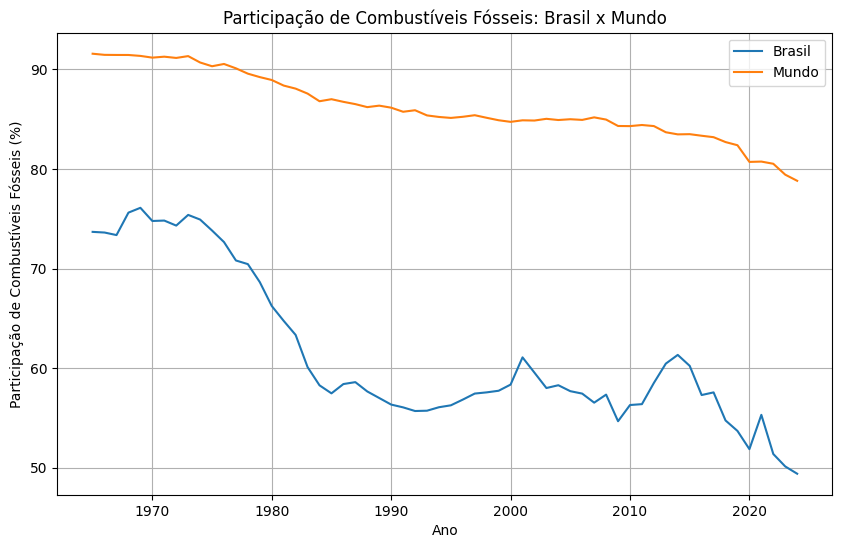

In [62]:
# PERGUNTA 8 - O Brasil apresenta menor dependência de combustíveis fósseis do que a média mundial ao longo do tempo?

#filtra os dados do Brasil
brasil_fosseis = df_matriz[
    df_matriz['country'] == 'Brazil'
][['year', 'fossil_share_energy']]

# calcula a média mundial
mundo_fosseis = (
    df_matriz
    .groupby('year')['fossil_share_energy']
    .mean()
    .reset_index()
)

# unifica dos dados do Brasil e do mundo
comparacao_fosseis = brasil_fosseis.merge(
    mundo_fosseis,
    on='year',
    suffixes=('_Brasil', '_Mundo')
)

# criação do gráfico de linhas com a comparação
plt.figure(figsize=(10, 6))

plt.plot(
    comparacao_fosseis['year'],
    comparacao_fosseis['fossil_share_energy_Brasil'],
    label='Brasil'
)

plt.plot(
    comparacao_fosseis['year'],
    comparacao_fosseis['fossil_share_energy_Mundo'],
    label='Mundo'
)

plt.title('Participação de Combustíveis Fósseis: Brasil x Mundo')
plt.xlabel('Ano')
plt.ylabel('Participação de Combustíveis Fósseis (%)')
plt.legend()
plt.grid(True)

plt.show()